### Setup

Importing the necessary libraries and configuring the plot settings.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

### User Input

Select the design you want to validate with the DTU data.

In [2]:
seed = 1
max_iter_label = 500

### Compare DTU and WESL for one seed

In this notebook, compare DTU and WESL using one selected seed.

It will show:
- the initial design used in this case
- the final layout from each method
- the AEP curve across iterations
- simple final metrics

In [6]:

project_root = Path.cwd().parents[0]

wesl_file = project_root / "Results" / f"WESL_100wt_seed_{seed}.csv"
dtu_file = project_root / "DTU_Recorders_Full_Compiled" / "sgd" / "rows_10_T" / f"dtu_100wt_T500_seed{seed}.csv"

design_file = project_root / "Designs" / "Cases_DTU" / "rows_10_T" / "100turb_3600m_kdt_1.csv"

print("WESL file :", wesl_file)
print("DTU file  :", dtu_file)
print("Design file:", design_file)

for file_path in [wesl_file, dtu_file, design_file]:
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

WESL file : /Users/brunoboer/Documents/Software/WESL_Optimizer/wesl/Optimizers_Bruno/Results/WESL_100wt_seed_1.csv
DTU file  : /Users/brunoboer/Documents/Software/WESL_Optimizer/wesl/Optimizers_Bruno/DTU_Recorders_Full_Compiled/sgd/rows_10_T/dtu_100wt_T500_seed1.csv
Design file: /Users/brunoboer/Documents/Software/WESL_Optimizer/wesl/Optimizers_Bruno/Designs/Cases_DTU/rows_10_T/100turb_3600m_kdt_1.csv


### Load data

In [7]:
df_wesl = pd.read_csv(wesl_file)
df_dtu = pd.read_csv(dtu_file)
df_design = pd.read_csv(design_file)

print("WESL columns :", df_wesl.columns.tolist())
print("DTU columns  :", df_dtu.columns.tolist())
print("Design columns:", df_design.columns.tolist())

WESL columns : ['eval', 'time_s', 'iter', 'obj', 'aep', 'x', 'y', 'rms_viol']
DTU columns  : ['eval', 'time_s', 'iter', 'obj', 'aep', 'rms_viol', 'x', 'y']
Design columns: ['x_coordinate', 'y_coordinate', 'x0', 'y0', 'x1', 'y1']


### Helpers

In [8]:


def parse_xy_string(x_value, y_value):
    x_str = str(x_value).strip().strip("\"'[]")
    y_str = str(y_value).strip().strip("\"'[]")

    xs = np.array([float(v.strip()) for v in x_str.split(";") if v.strip() != ""])
    ys = np.array([float(v.strip()) for v in y_str.split(";") if v.strip() != ""])

    if len(xs) != len(ys):
        raise ValueError("x and y have different lengths.")

    return np.column_stack((xs, ys))


def get_boundary_from_design(df):
    x0 = float(df["x0"].iloc[0])
    y0 = float(df["y0"].iloc[0])
    x1 = float(df["x1"].iloc[0])
    y1 = float(df["y1"].iloc[0])
    return x0, y0, x1, y1


def get_initial_layout_from_design(df):
    return df[["x_coordinate", "y_coordinate"]].to_numpy()


def get_final_layout(df):
    return parse_xy_string(df.iloc[-1]["x"], df.iloc[-1]["y"])

### Extracted Data

In [9]:
initial_layout = get_initial_layout_from_design(df_design)
final_layout_wesl = get_final_layout(df_wesl)
final_layout_dtu = get_final_layout(df_dtu)

x0, y0, x1, y1 = get_boundary_from_design(df_design)

print("Initial turbines:", initial_layout.shape[0])
print("Final WESL turbines:", final_layout_wesl.shape[0])
print("Final DTU turbines :", final_layout_dtu.shape[0])
print("Boundary:", (x0, y0), "to", (x1, y1))

Initial turbines: 100
Final WESL turbines: 100
Final DTU turbines : 100
Boundary: (0.0, 0.0) to (3600.0, 3600.0)


### Initial design for `seed`

This plot shows the initial turbine layout used in this case.

It gives a quick view of the wind farm design before the optimization.

### Initial design plot :

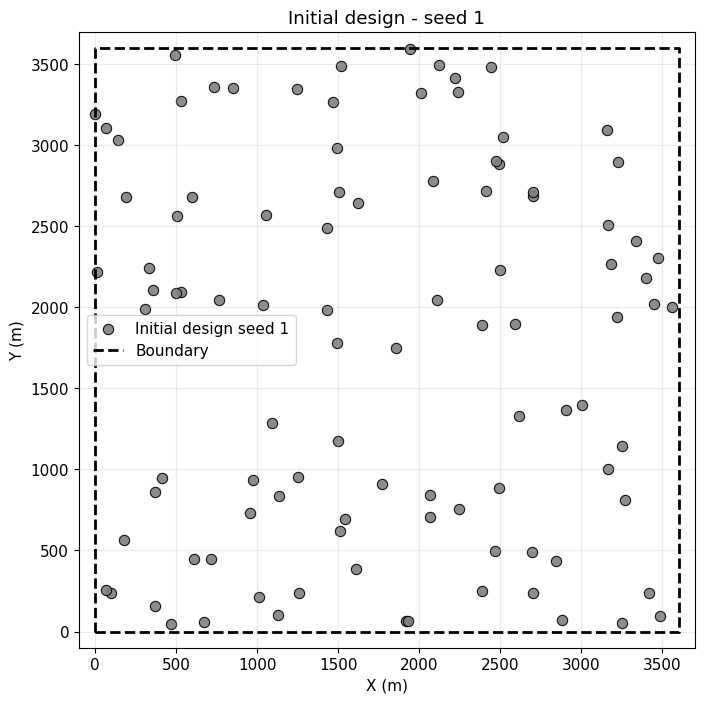

In [10]:

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    initial_layout[:, 0],
    initial_layout[:, 1],
    s=55,
    c="gray",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.9,
    label=f"Initial design seed {seed}"
)

ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "k--", linewidth=2, label="Boundary")

ax.set_title(f"Initial design - seed {seed}")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_xlim(x0 - 100, x1 + 100)
ax.set_ylim(y0 - 100, y1 + 100)
ax.set_aspect("equal")
ax.legend()

plt.show()

### Final layouts

Now we show the final layout from each method (SGD Wesl and DTU).


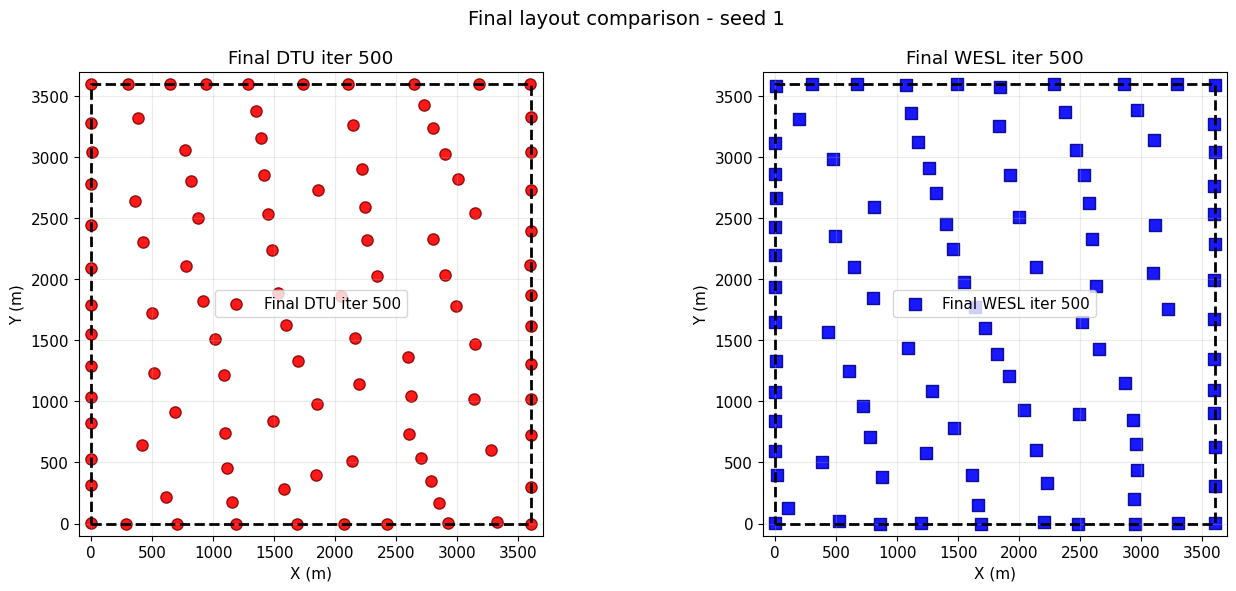

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DTU
axes[0].scatter(
    final_layout_dtu[:, 0],
    final_layout_dtu[:, 1],
    s=65,
    c="red",
    edgecolors="darkred",
    linewidths=1.0,
    alpha=0.9,
    label=f"Final DTU iter {max_iter_label}"
)
axes[0].plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "k--", linewidth=2)
axes[0].set_title(f"Final DTU iter {max_iter_label}")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[0].set_xlim(x0 - 100, x1 + 100)
axes[0].set_ylim(y0 - 100, y1 + 100)
axes[0].set_aspect("equal")
axes[0].legend()

# WESL
axes[1].scatter(
    final_layout_wesl[:, 0],
    final_layout_wesl[:, 1],
    s=65,
    c="blue",
    edgecolors="darkblue",
    linewidths=1.0,
    alpha=0.9,
    marker="s",
    label=f"Final WESL iter {max_iter_label}"
)
axes[1].plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "k--", linewidth=2)
axes[1].set_title(f"Final WESL iter {max_iter_label}")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")
axes[1].set_xlim(x0 - 100, x1 + 100)
axes[1].set_ylim(y0 - 100, y1 + 100)
axes[1].set_aspect("equal")
axes[1].legend()

fig.suptitle(f"Final layout comparison - seed {seed}", fontsize=14)
plt.tight_layout()
plt.show()

### AEP across iterations

This plot compares how AEP changes during the optimization.


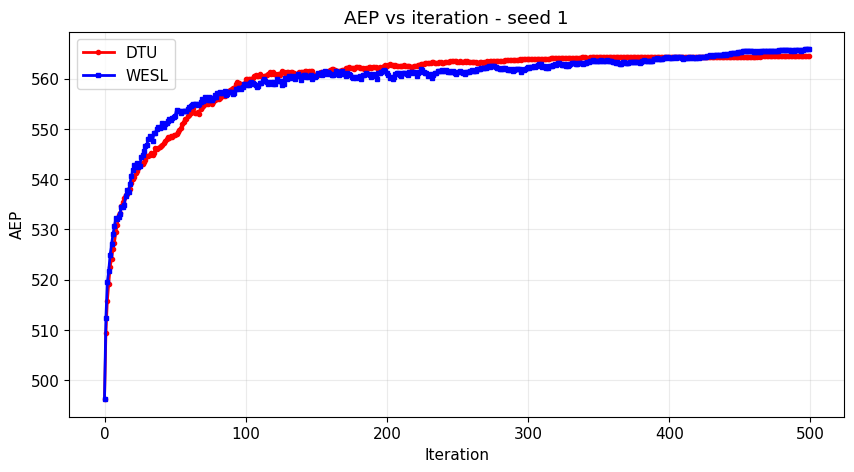

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_dtu["iter"],
    df_dtu["aep"],
    color="red",
    marker="o",
    markersize=3,
    linewidth=2,
    label="DTU"
)

ax.plot(
    df_wesl["iter"],
    df_wesl["aep"],
    color="blue",
    marker="s",
    markersize=3,
    linewidth=2,
    label="WESL"
)

ax.set_title(f"AEP vs iteration - seed {seed}")
ax.set_xlabel("Iteration")
ax.set_ylabel("AEP")
ax.legend()

plt.show()

### Final metrics


In [13]:
aep_initial_dtu = df_dtu["aep"].iloc[0]
aep_final_dtu = df_dtu["aep"].iloc[-1]
rms_final_dtu = df_dtu["rms_viol"].iloc[-1]

aep_initial_wesl = df_wesl["aep"].iloc[0]
aep_final_wesl = df_wesl["aep"].iloc[-1]
rms_final_wesl = df_wesl["rms_viol"].iloc[-1]

print(f"Seed: {seed}")
print()

print("DTU")
print(f"  Initial AEP      : {aep_initial_dtu}")
print(f"  Final AEP        : {aep_final_dtu}")
print(f"  Final RMS viol   : {rms_final_dtu}")
print()

print("WESL")
print(f"  Initial AEP      : {aep_initial_wesl}")
print(f"  Final AEP        : {aep_final_wesl}")
print(f"  Final RMS viol   : {rms_final_wesl}")

Seed: 1

DTU
  Initial AEP      : 496.2298788690755
  Final AEP        : 564.4321170653161
  Final RMS viol   : 0.0019379586704908

WESL
  Initial AEP      : 496.2298789145759
  Final AEP        : 565.8162725384278
  Final RMS viol   : 0.0930414969299643
